# 충전 정책과 상세 cycle 탐색 — N04–N06

첫 묶음의 세 전략을 실행한다. 원본 단위를 유지하고 셀·정책별 관찰을 수명 인과효과와 구별한다. 출력은 `outputs/figures/policy_exploration/`에 저장한다.

In [1]:
from pathlib import Path
import sys
cwd=Path.cwd().resolve()
PROJECT_ROOT=next(p for p in [cwd,*cwd.parents] if (p/'src/policy_eda.py').is_file())
if str(PROJECT_ROOT) not in sys.path:sys.path.insert(0,str(PROJECT_ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src import policy_eda as pe
OUTPUT_DIR=PROJECT_ROOT/'outputs/figures/policy_exploration'
gallery=pd.read_csv(PROJECT_ROOT/'outputs/figures/question_gallery/cell_features_for_gallery.csv')
features,policies,traces,audit,group_stats=pe.build_policy_data(PROJECT_ROOT/'data/raw',gallery)
pe.save_tables(OUTPUT_DIR,features,policies,traces,audit,group_stats)
print('Cell counts:', features.groupby('batch').size().to_dict())
print('Detailed cycles:',len(traces),'Alignment checks passed:',int(audit.alignment_passed.sum()))
display(policies)

Matplotlib is building the font cache; this may take a moment.


Cell counts: {'batch1': 46, 'batch2': 47, 'batch3': 46}
Detailed cycles: 15 Alignment checks passed: 15


,batch,charging_policy,n_total,n_life,chargetime_min,chargetime_max,chargetime_mean,peak_I_min,peak_I_max
0,batch1,3.6C(80%)-3.6C,3,3,13.372038,13.384324,13.378589,3.600702,3.601255
1,batch1,4.4C(80%)-4.4C,1,1,15.437651,15.437651,15.437651,4.400767,4.400767
2,batch1,4.8C(80%)-4.8C,2,2,10.043405,10.044430,10.043918,4.800308,4.800375
3,batch1,4C(80%)-4C,2,2,12.053526,12.053579,12.053552,4.000961,4.001638
4,batch1,5.4C(40%)-3.6C,2,2,11.243821,11.245707,11.244764,5.402551,5.403460
5,batch1,5.4C(50%)-3.6C,2,2,10.682911,10.683664,10.683287,5.401747,5.401799
6,batch1,5.4C(50%)-3C,2,2,11.685092,11.686670,11.685881,5.401535,5.410184
7,batch1,5.4C(60%)-3.6C,2,2,10.125278,10.138984,10.132131,5.405922,5.405946
8,batch1,5.4C(60%)-3C,2,2,15.291006,15.291829,15.291418,5.402489,5.407163
9,batch1,5.4C(70%)-3C,2,2,9.925855,9.930556,9.928205,5.401563,5.404739


## N04 — 충전 시간·전류와 정책

위 산점도의 정책 코드 Pxx는 아래 정책별 분포의 이름과 연결된다. 코드·색은 batch별로 정의되며 수명 누락 셀도 포함한다. 원본 전류 스케일과 정책의 C-rate를 동일한 단위로 가정하지 않는다.

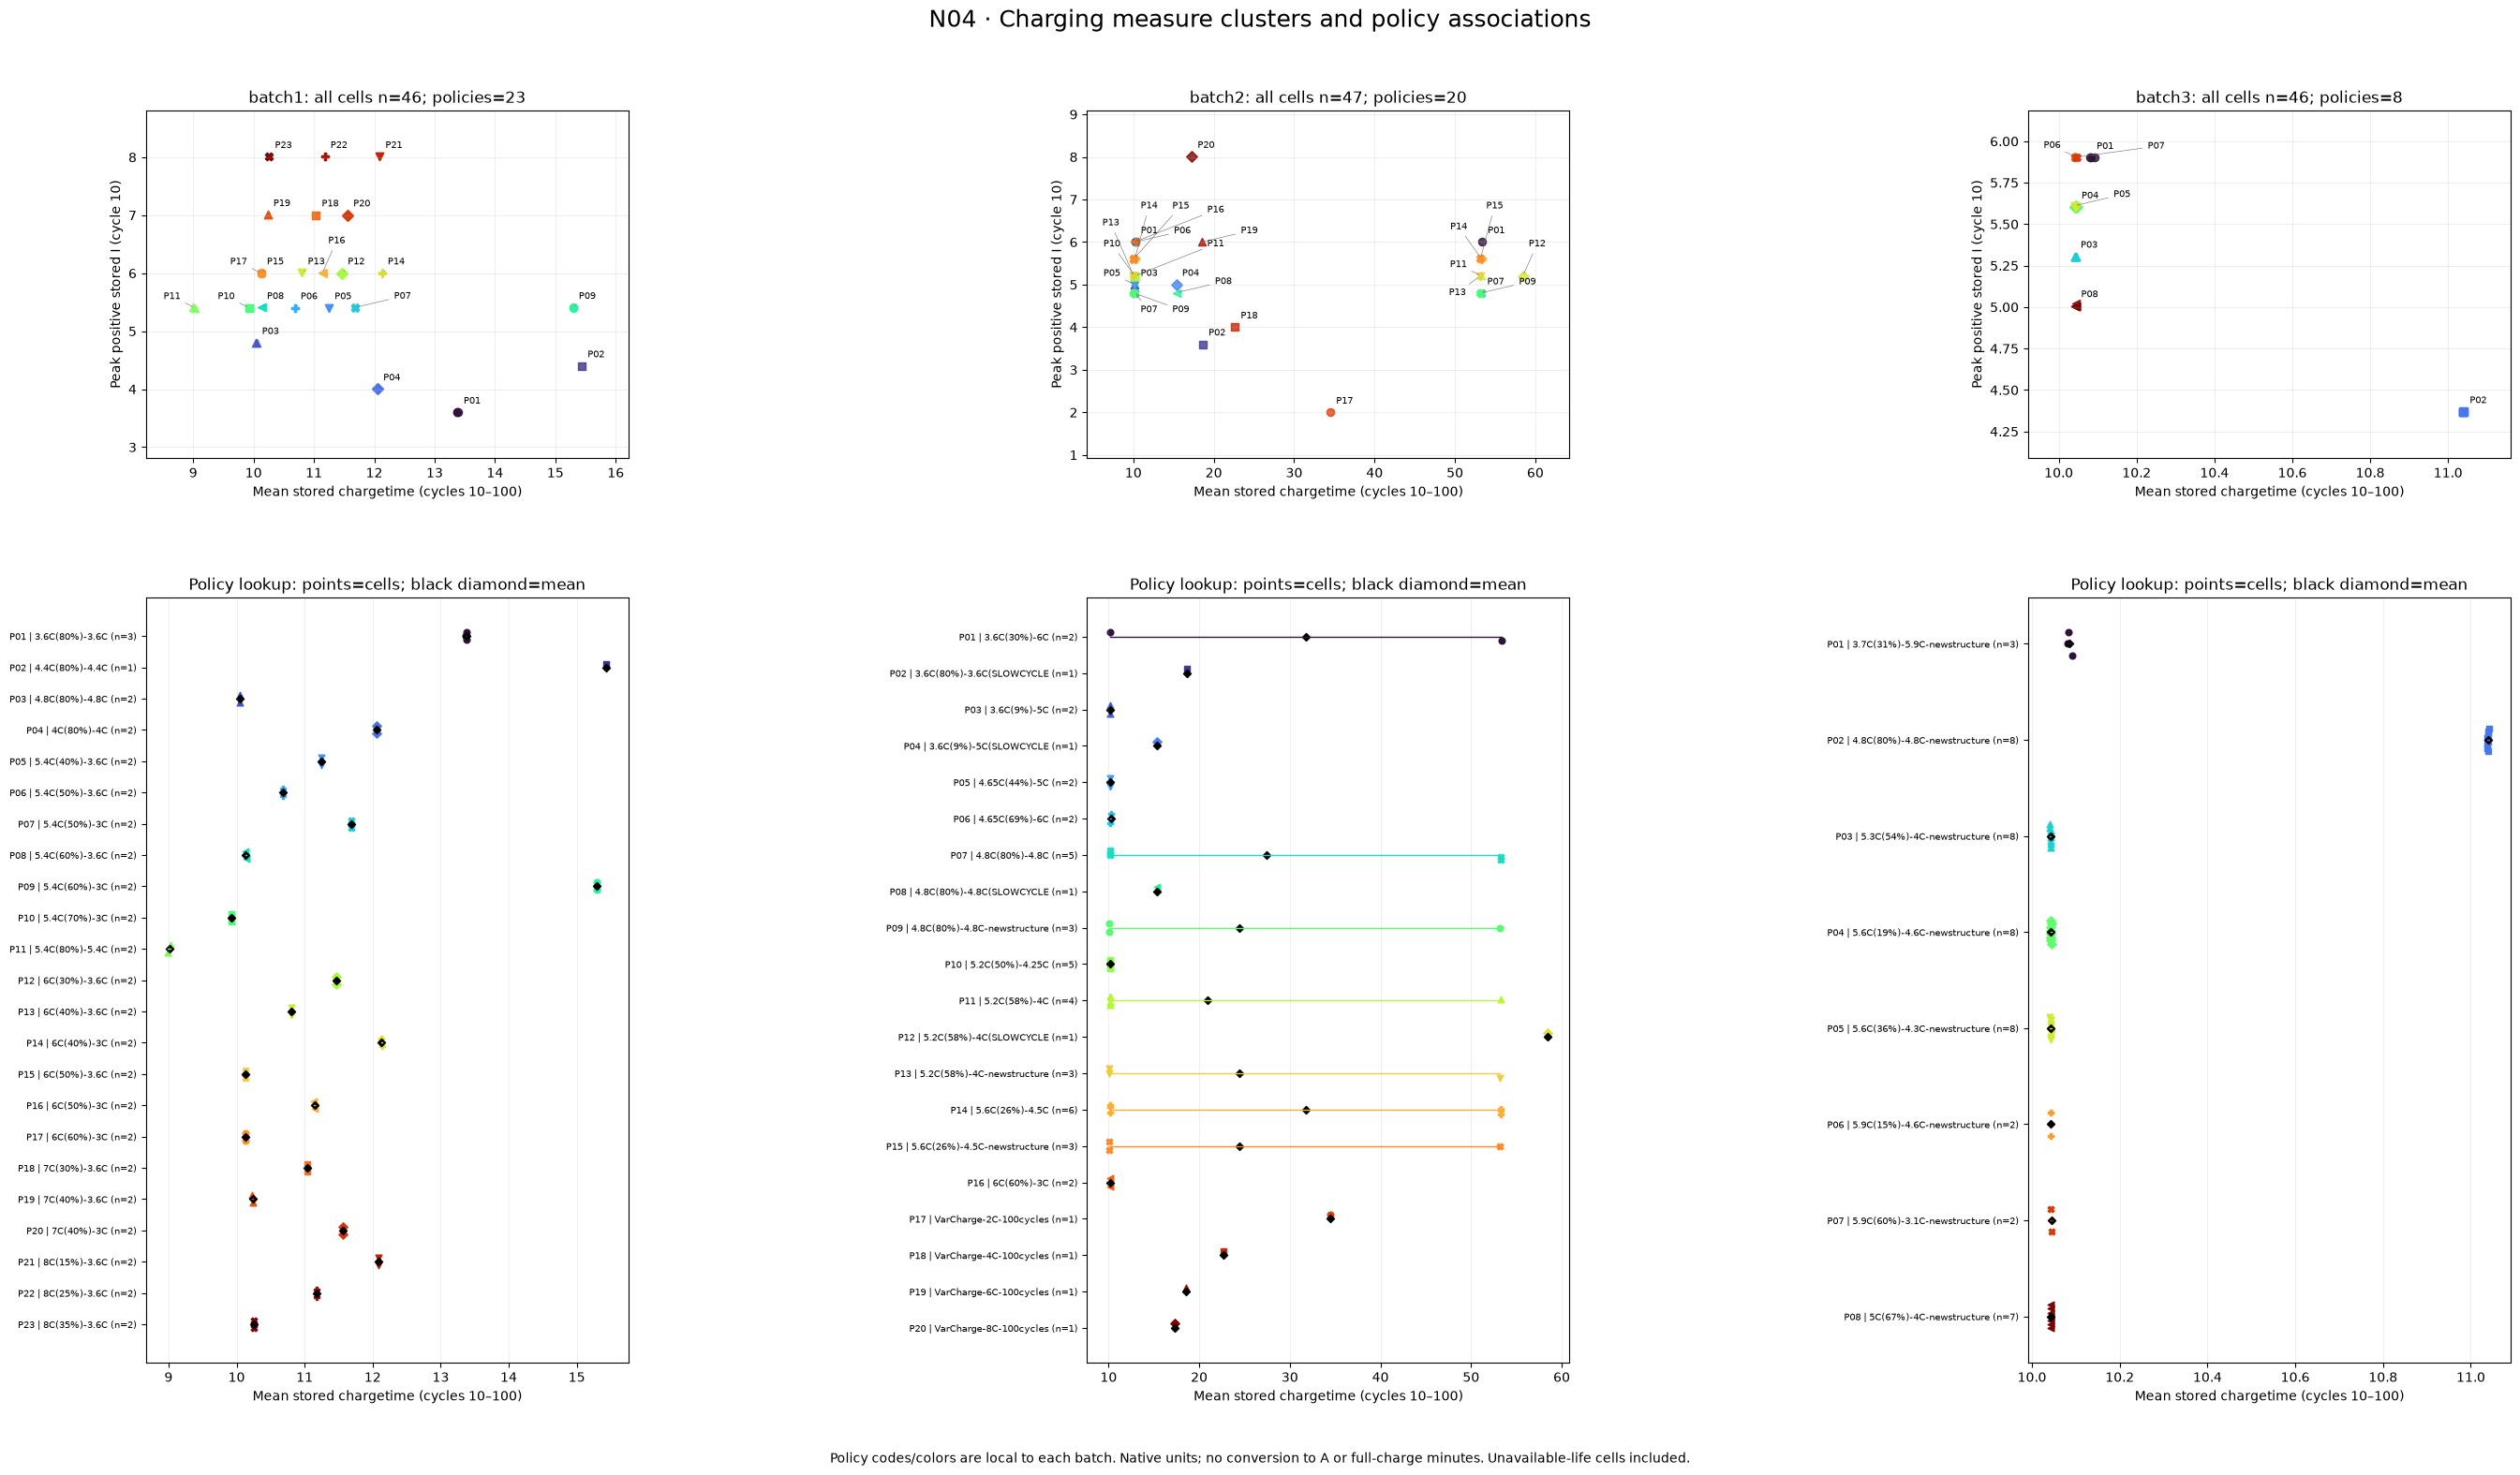

In [2]:
fig=pe.figure_policy_measures(features)
fig.savefig(OUTPUT_DIR/'N04_charging_policy_associations.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

## N05 — 한 cycle의 상세 기록

각 batch에서 다른 정책의 셀 3개를 선택했다. 선택은 전체를 대표하는 통계 표본이 아니다. batch1: 0·3·44, batch2: 0·38·22, batch3: 6·7·3. cycle 10을 비교하고, 별도로 batch1 cell 0의 11–13 및 batch2 cell 38의 99–101을 확인한다. 시간·전류·전압·용량은 원본 수치다. 점선은 ±0.05의 탐색용 전류 범위로 구분한 부호/정지 상태 전환이다.

인접 시간 간격이 양수 간격 중앙값의 20배를 넘는 구간은 회색으로 표시하고 선을 끊는다. 관측점이 없는 구간을 연속 변화처럼 연결하지 않는다.

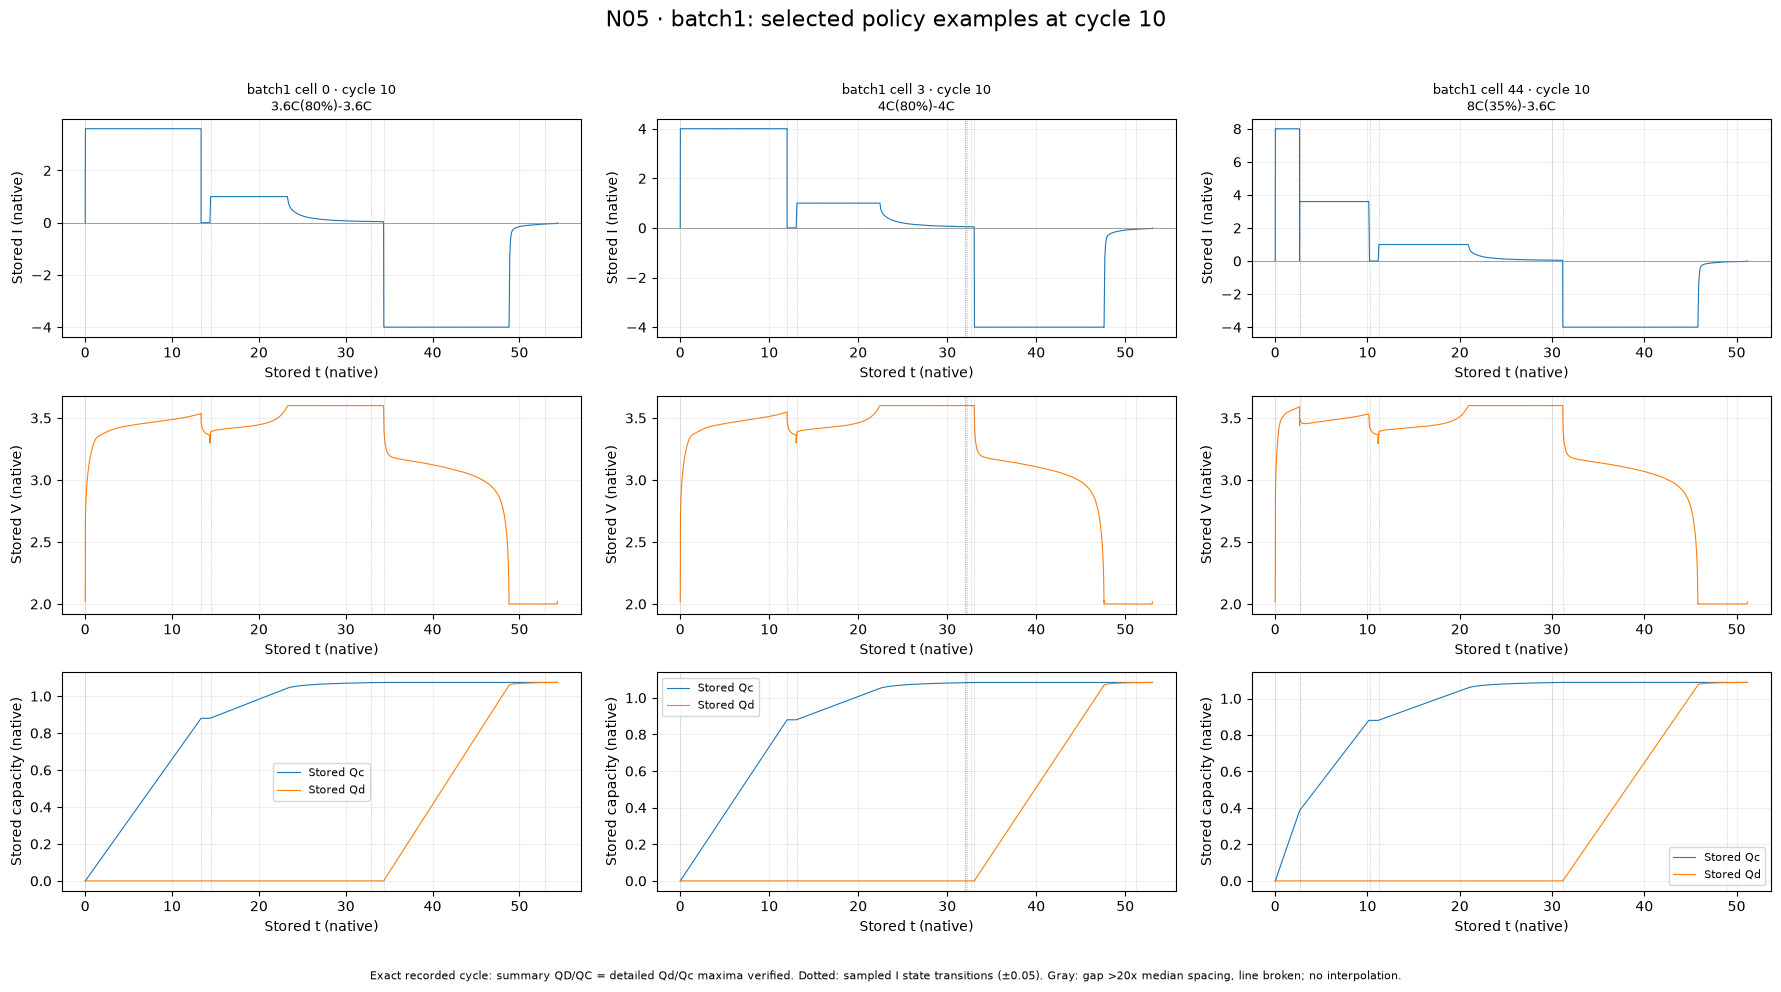

In [3]:
records=[r for r in traces if r['batch']=='batch1' and r['reason']=='policy_examples']
fig=pe.figure_traces(records,'N05 · batch1: selected policy examples at cycle 10')
fig.savefig(OUTPUT_DIR/'N05_batch1_cycle10.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

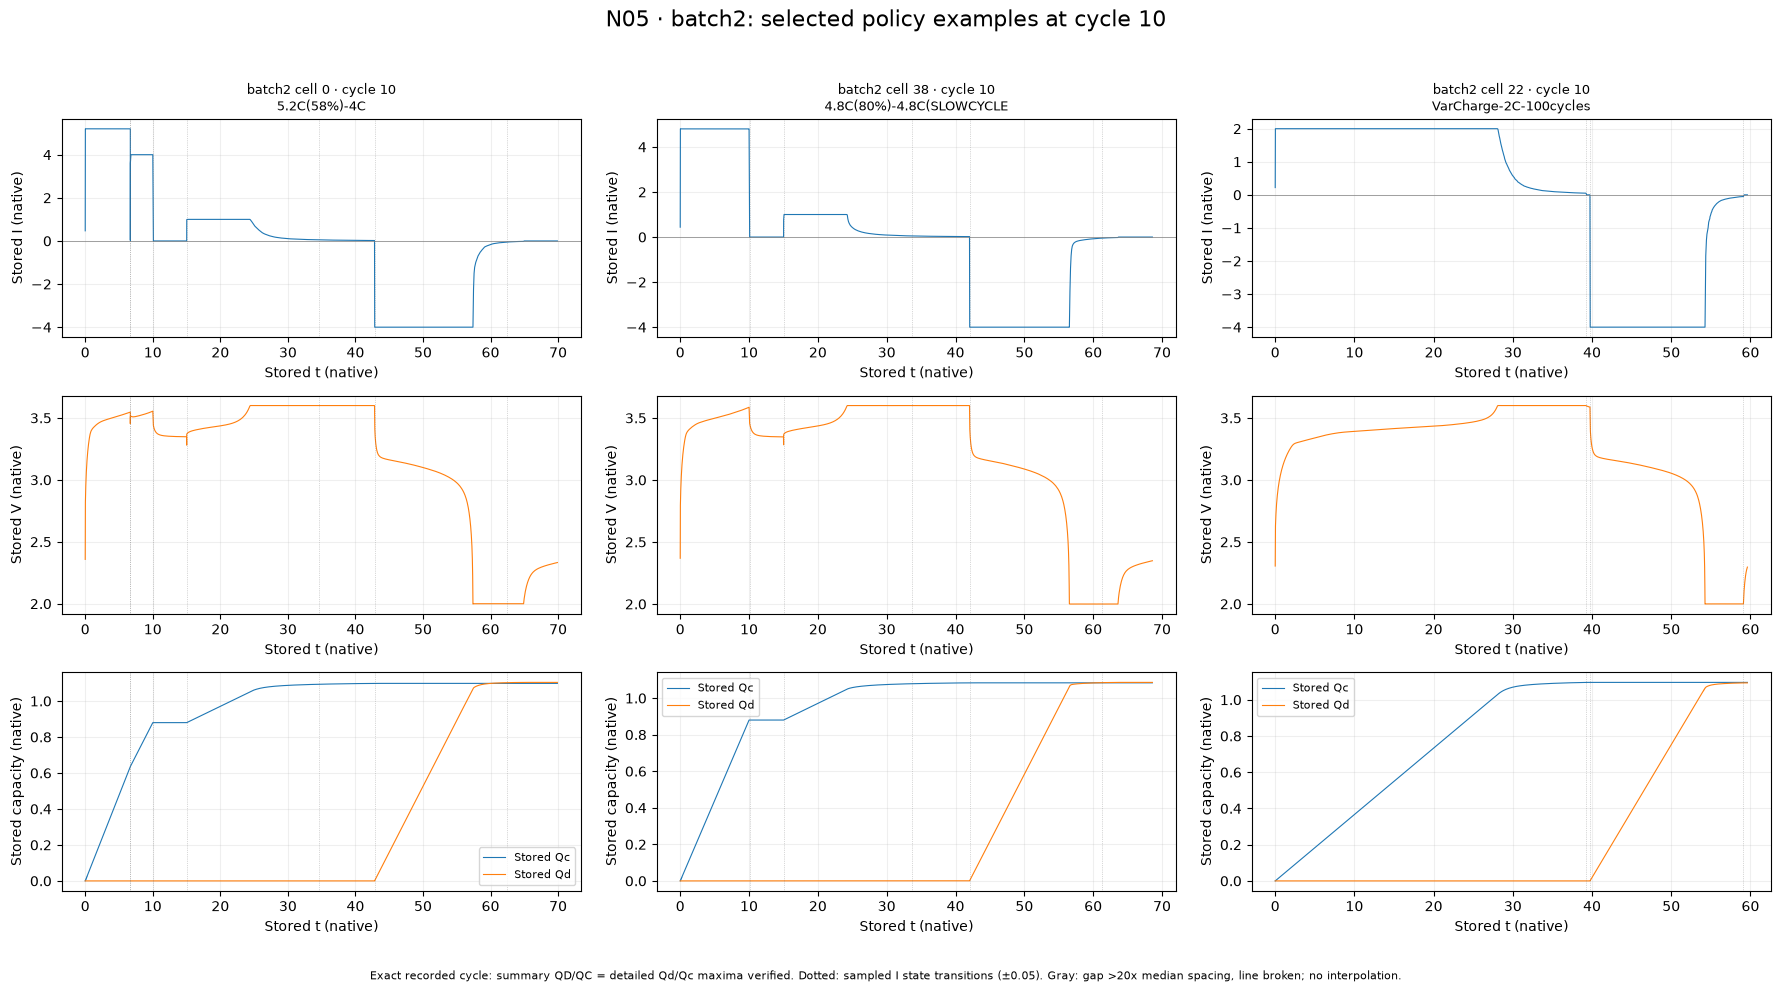

In [4]:
records=[r for r in traces if r['batch']=='batch2' and r['reason']=='policy_examples']
fig=pe.figure_traces(records,'N05 · batch2: selected policy examples at cycle 10')
fig.savefig(OUTPUT_DIR/'N05_batch2_cycle10.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

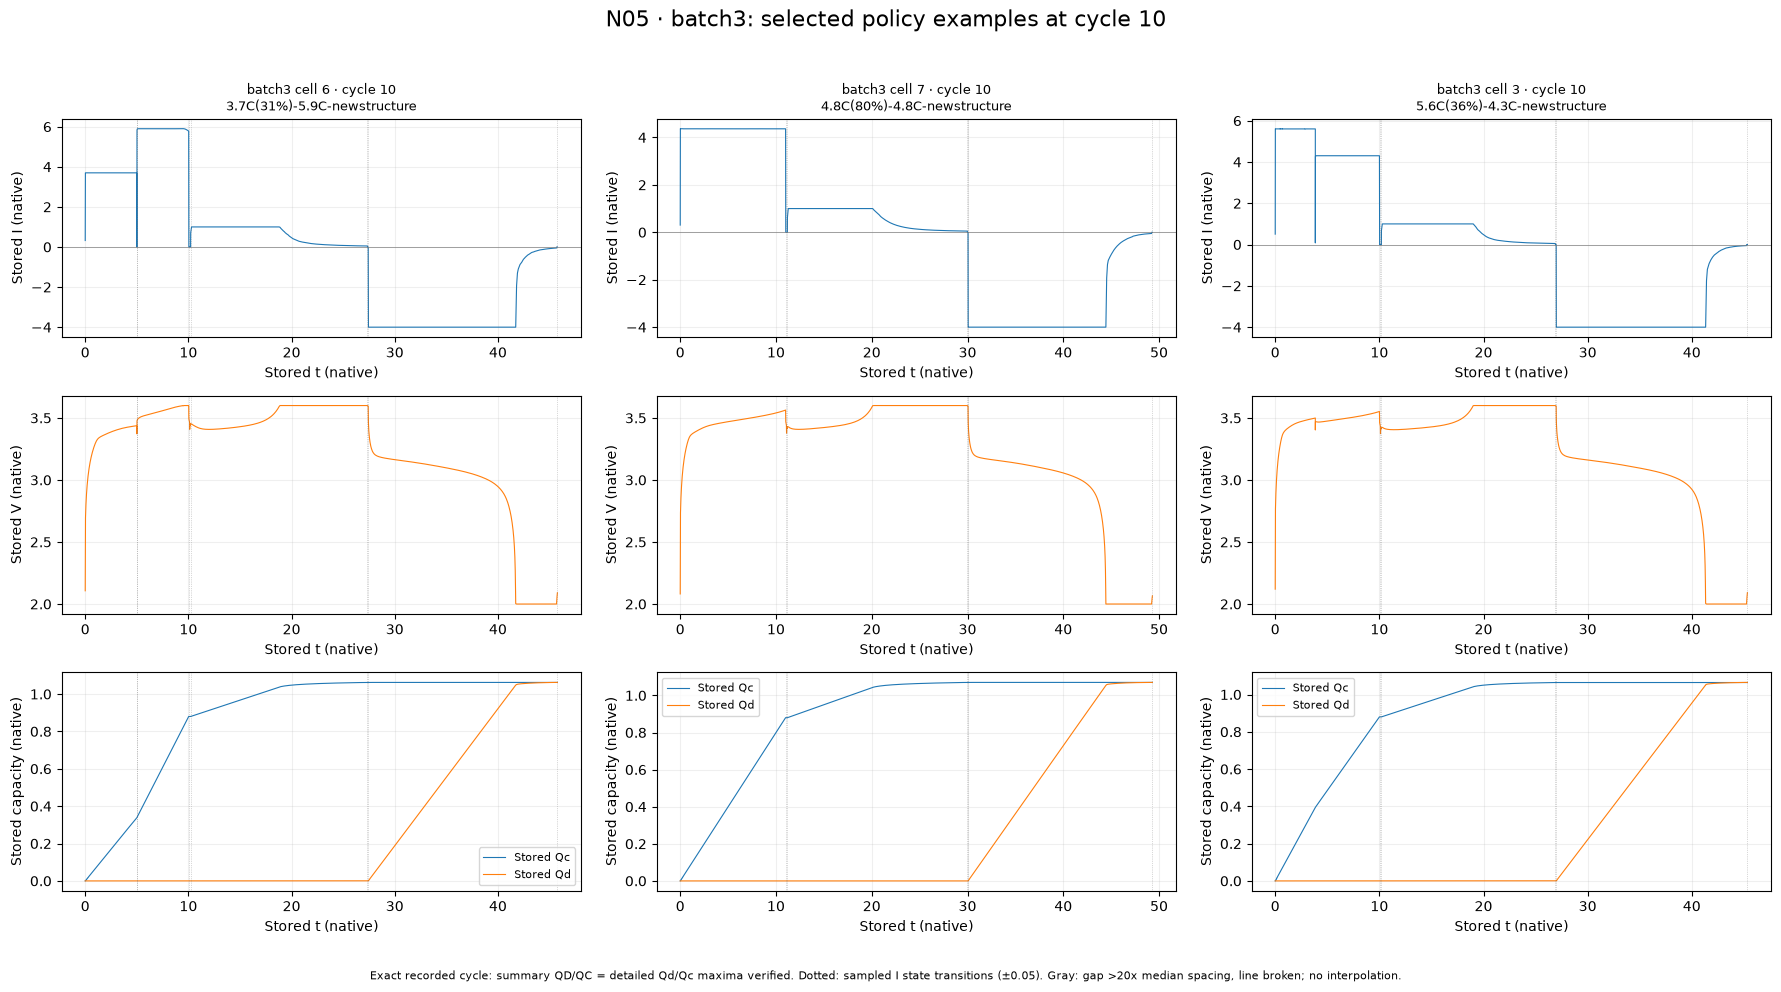

In [5]:
records=[r for r in traces if r['batch']=='batch3' and r['reason']=='policy_examples']
fig=pe.figure_traces(records,'N05 · batch3: selected policy examples at cycle 10')
fig.savefig(OUTPUT_DIR/'N05_batch3_cycle10.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

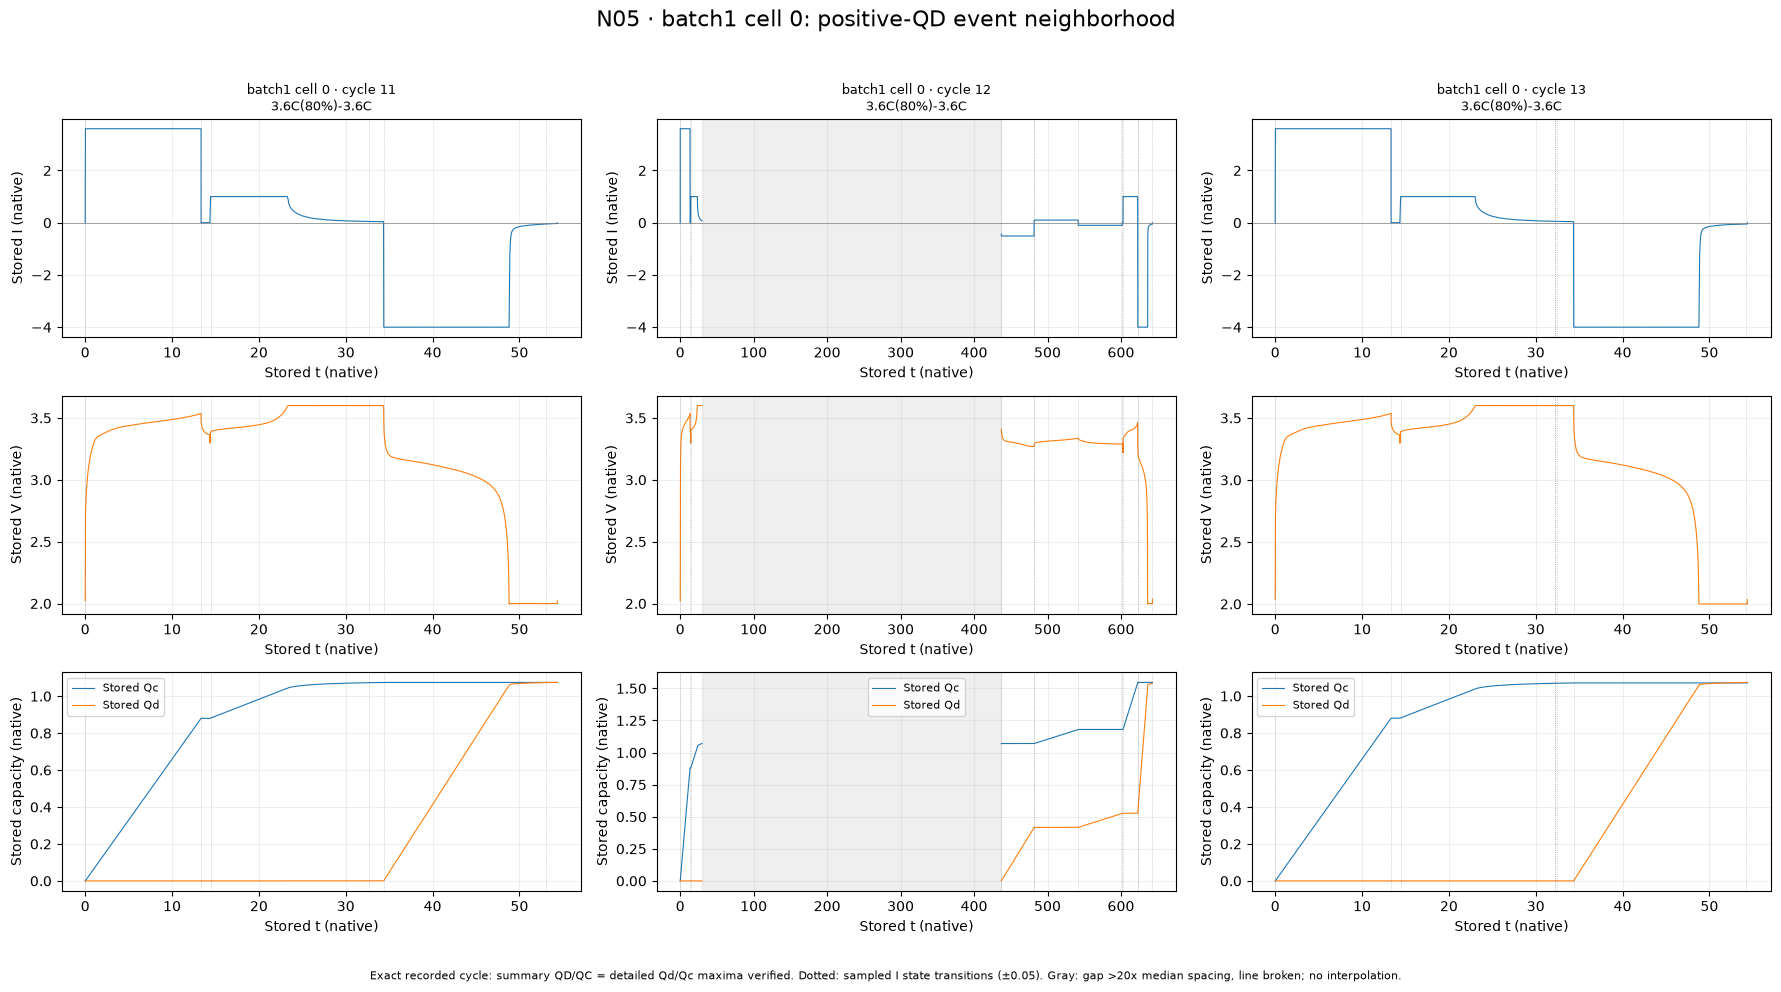

In [6]:
records=[r for r in traces if r['batch']=='batch1' and r['cell_id']==0 and r['reason']=='event_neighborhood']
fig=pe.figure_traces(records,'N05 · batch1 cell 0: positive-QD event neighborhood')
fig.savefig(OUTPUT_DIR/'N05_batch1_cell0_event.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

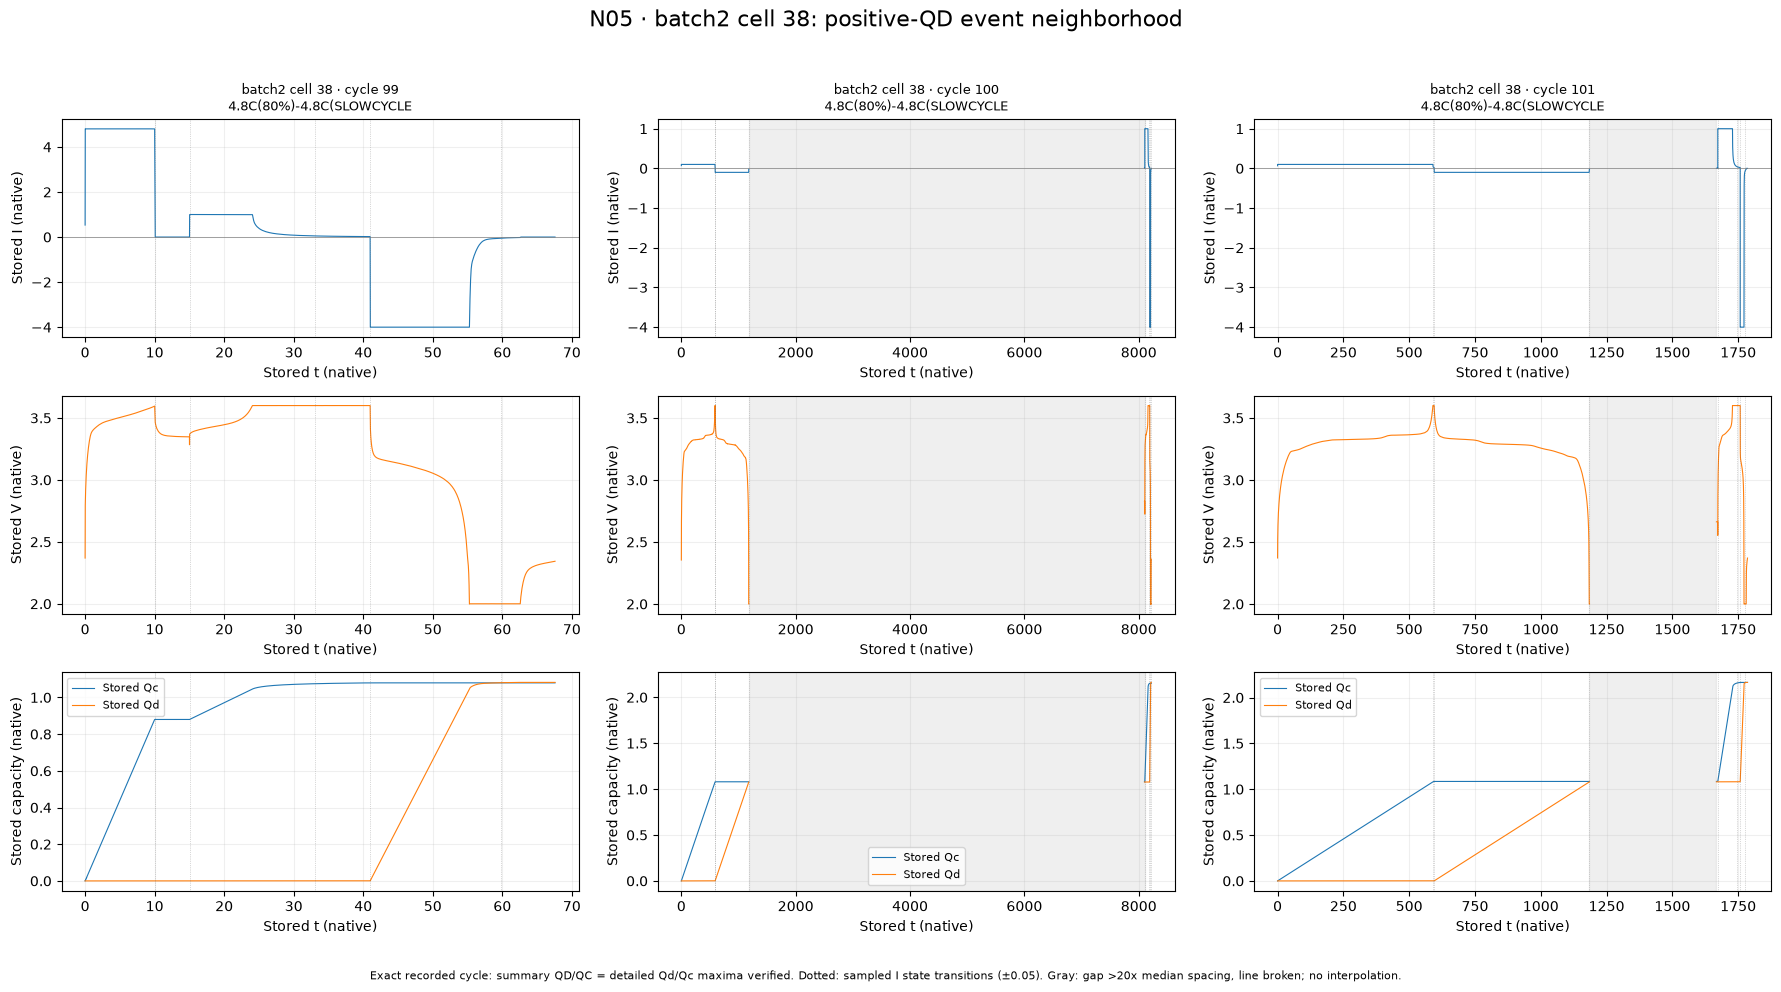

In [7]:
records=[r for r in traces if r['batch']=='batch2' and r['cell_id']==38 and r['reason']=='event_neighborhood']
fig=pe.figure_traces(records,'N05 · batch2 cell 38: positive-QD event neighborhood')
fig.savefig(OUTPUT_DIR/'N05_batch2_cell38_event.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

In [8]:
display(audit)

,batch,cell_id,cycle,reason,charging_policy,storage_index,alignment_passed,samples,time_start_native,time_end_native,...,min_I_native,max_Qc,max_Qd,largest_time_gap_native,large_time_gaps,direction_transitions,positive_blocks,negative_blocks,Qc_increase_positive_steps,Qd_increase_negative_steps
0,batch1,0,10,policy_examples,3.6C(80%)-3.6C,9,True,1130,0.0,54.374815,...,-4.001122,1.074353,1.074537,0.084460,0,6,2,1,413,267
1,batch1,3,10,policy_examples,4C(80%)-4C,9,True,1090,0.0,53.048778,...,-4.000929,1.083840,1.084308,0.084362,0,10,4,1,409,263
2,batch1,44,10,policy_examples,8C(35%)-3.6C,9,True,1060,0.0,51.169967,...,-4.001900,1.088295,1.088216,0.084495,0,8,3,1,373,257
3,batch1,0,11,event_neighborhood,3.6C(80%)-3.6C,10,True,1133,0.0,54.374552,...,-4.000779,1.074645,1.074781,0.084422,0,6,2,1,410,268
4,batch1,0,12,event_neighborhood,3.6C(80%)-3.6C,11,True,2730,0.0,642.784345,...,-4.002029,1.546792,1.539054,407.400262,1,12,4,3,977,908
5,batch1,0,13,event_neighborhood,3.6C(80%)-3.6C,12,True,1145,0.0,54.375763,...,-4.001167,1.071022,1.073827,0.084407,0,8,3,1,407,282
6,batch2,0,10,policy_examples,5.2C(58%)-4C,9,True,1028,0.0,69.895615,...,-4.000992,1.098234,1.103718,0.084642,0,7,3,1,384,280
7,batch2,38,10,policy_examples,4.8C(80%)-4.8C(SLOWCYCLE,9,True,993,0.0,68.600403,...,-4.001290,1.083667,1.086013,0.084540,0,5,2,1,372,273
8,batch2,22,10,policy_examples,VarCharge-2C-100cycles,9,True,1270,0.0,59.613743,...,-4.001636,1.096050,1.093309,0.084530,0,3,1,1,592,331
9,batch2,38,99,event_neighborhood,4.8C(80%)-4.8C(SLOWCYCLE,98,True,980,0.0,67.579547,...,-4.001424,1.079552,1.082088,0.084535,0,5,2,1,365,280


## N06 — 정책 내부의 ΔQ–수명 관계

정책별 작은 패널과 전체 비교 패널을 사용한다. 동일한 축, 셀 ID, n을 표시한다. 상관은 n≥5이고 두 값이 일정하지 않을 때만 계산한다. Pearson은 log10 분산 기준으로 기존 원분산 Pearson과 구별한다. 수명 그룹 내부 결과는 보조 CSV에 저장하며, 타깃 범위 제한의 영향을 받는 탐색이다.

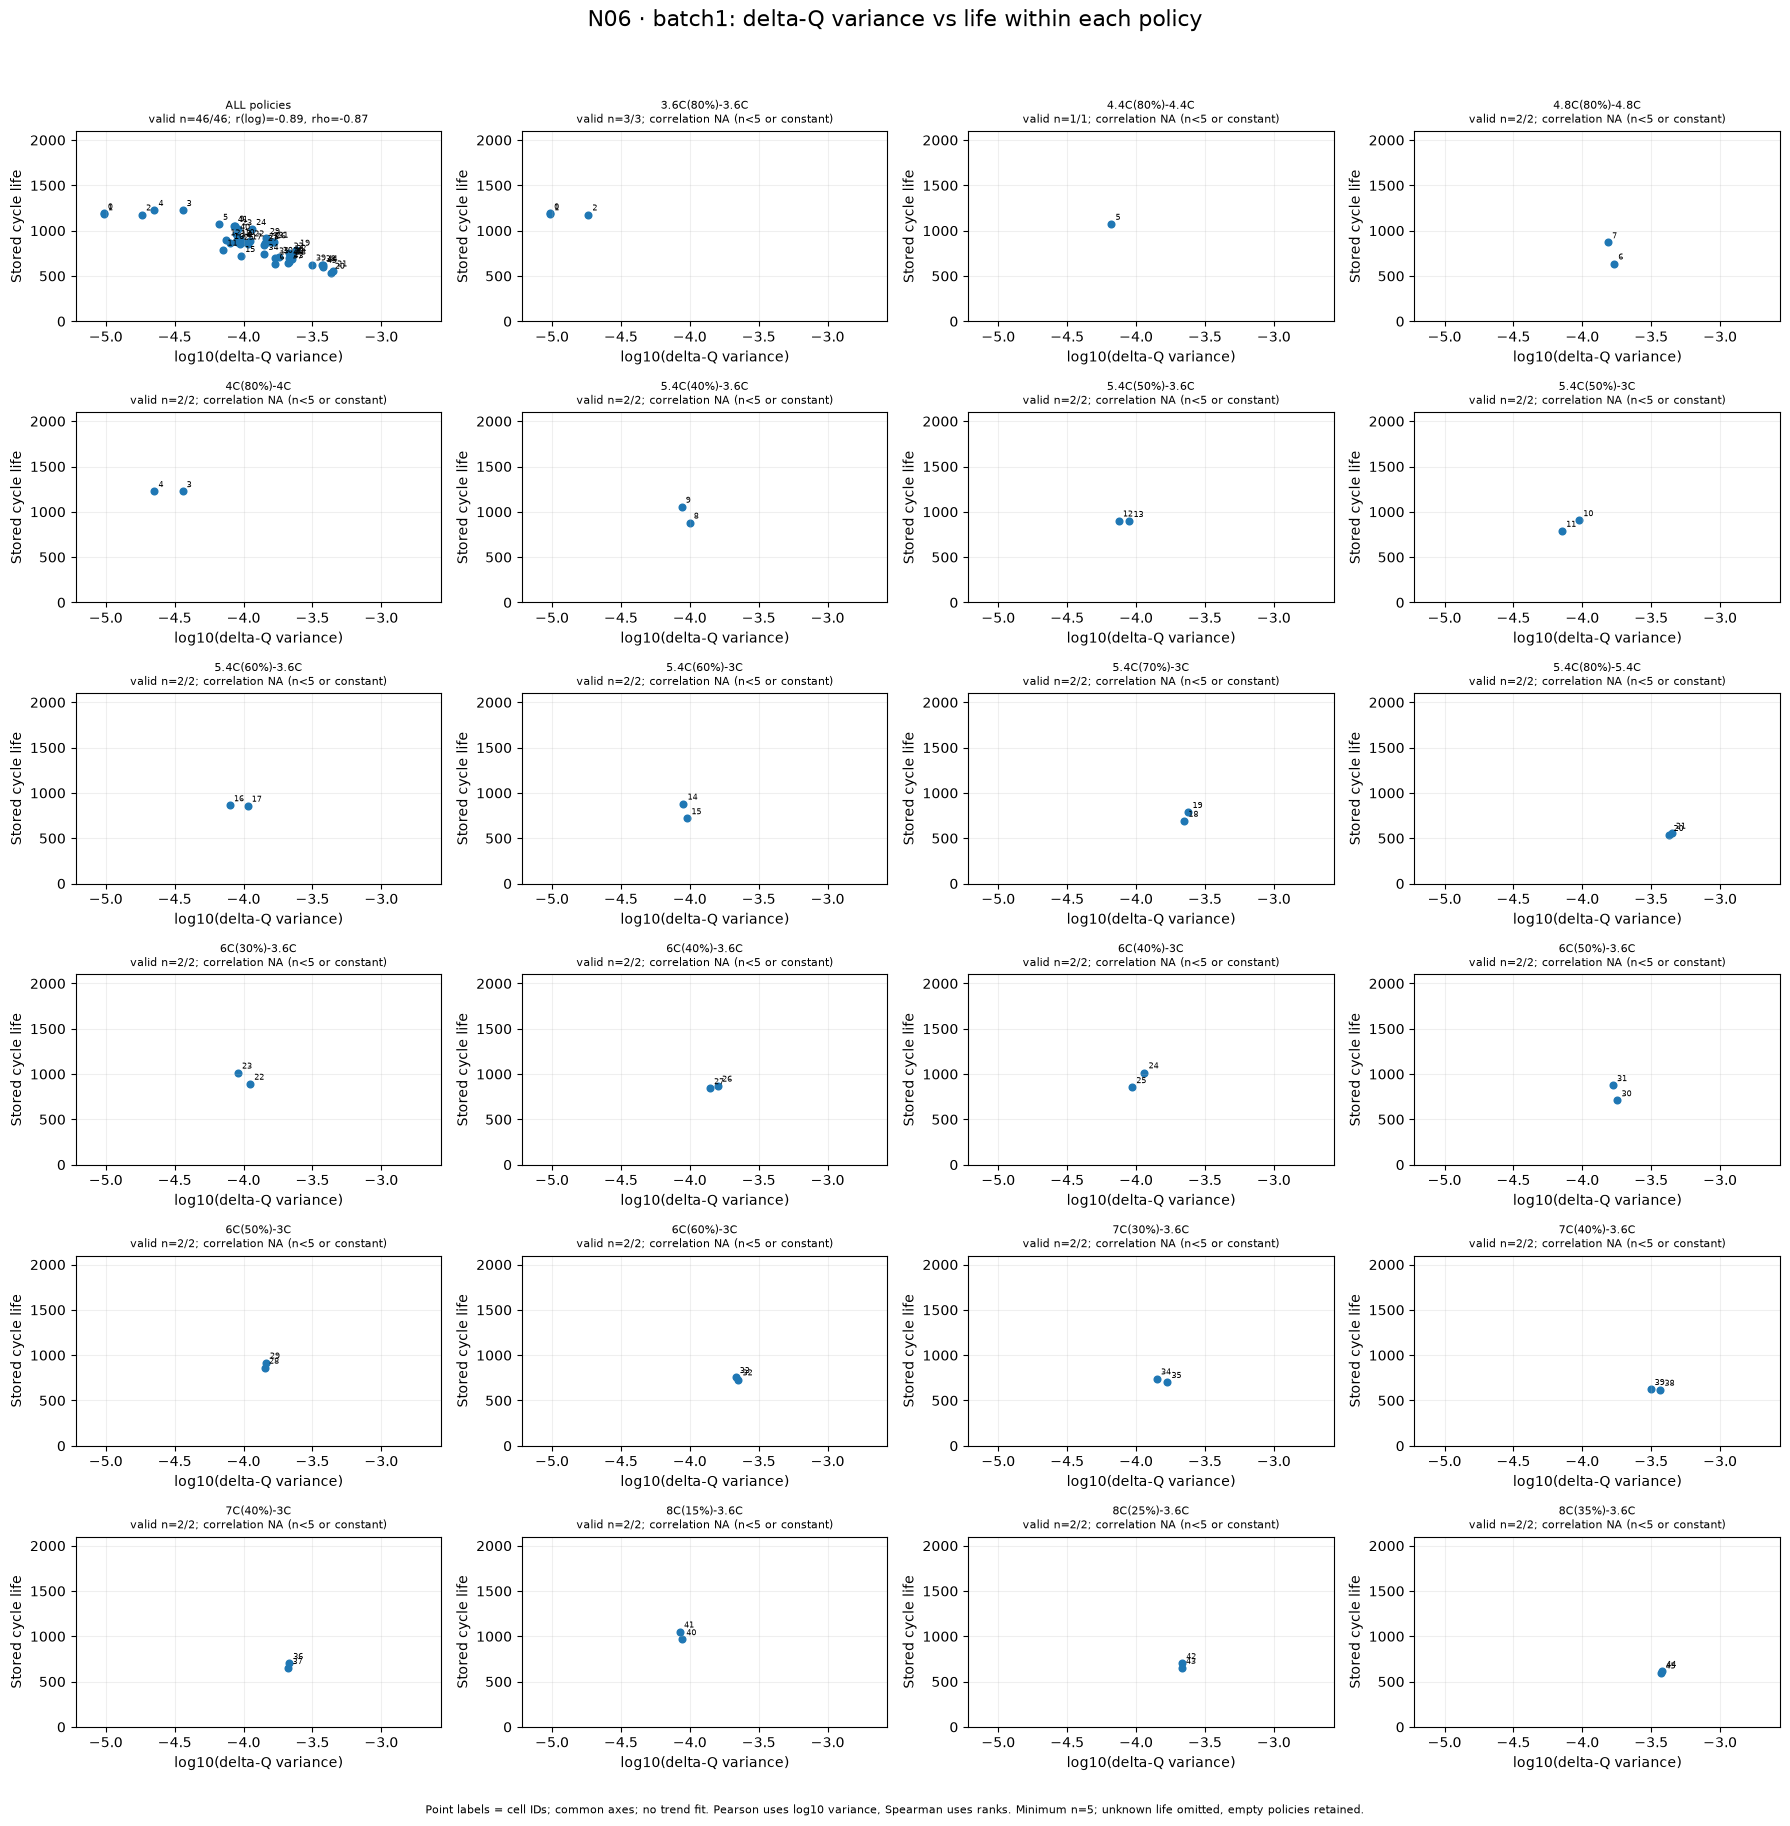

In [9]:
fig=pe.figure_within_policy(features,'batch1',group_stats)
fig.savefig(OUTPUT_DIR/'N06_batch1_within_policy.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

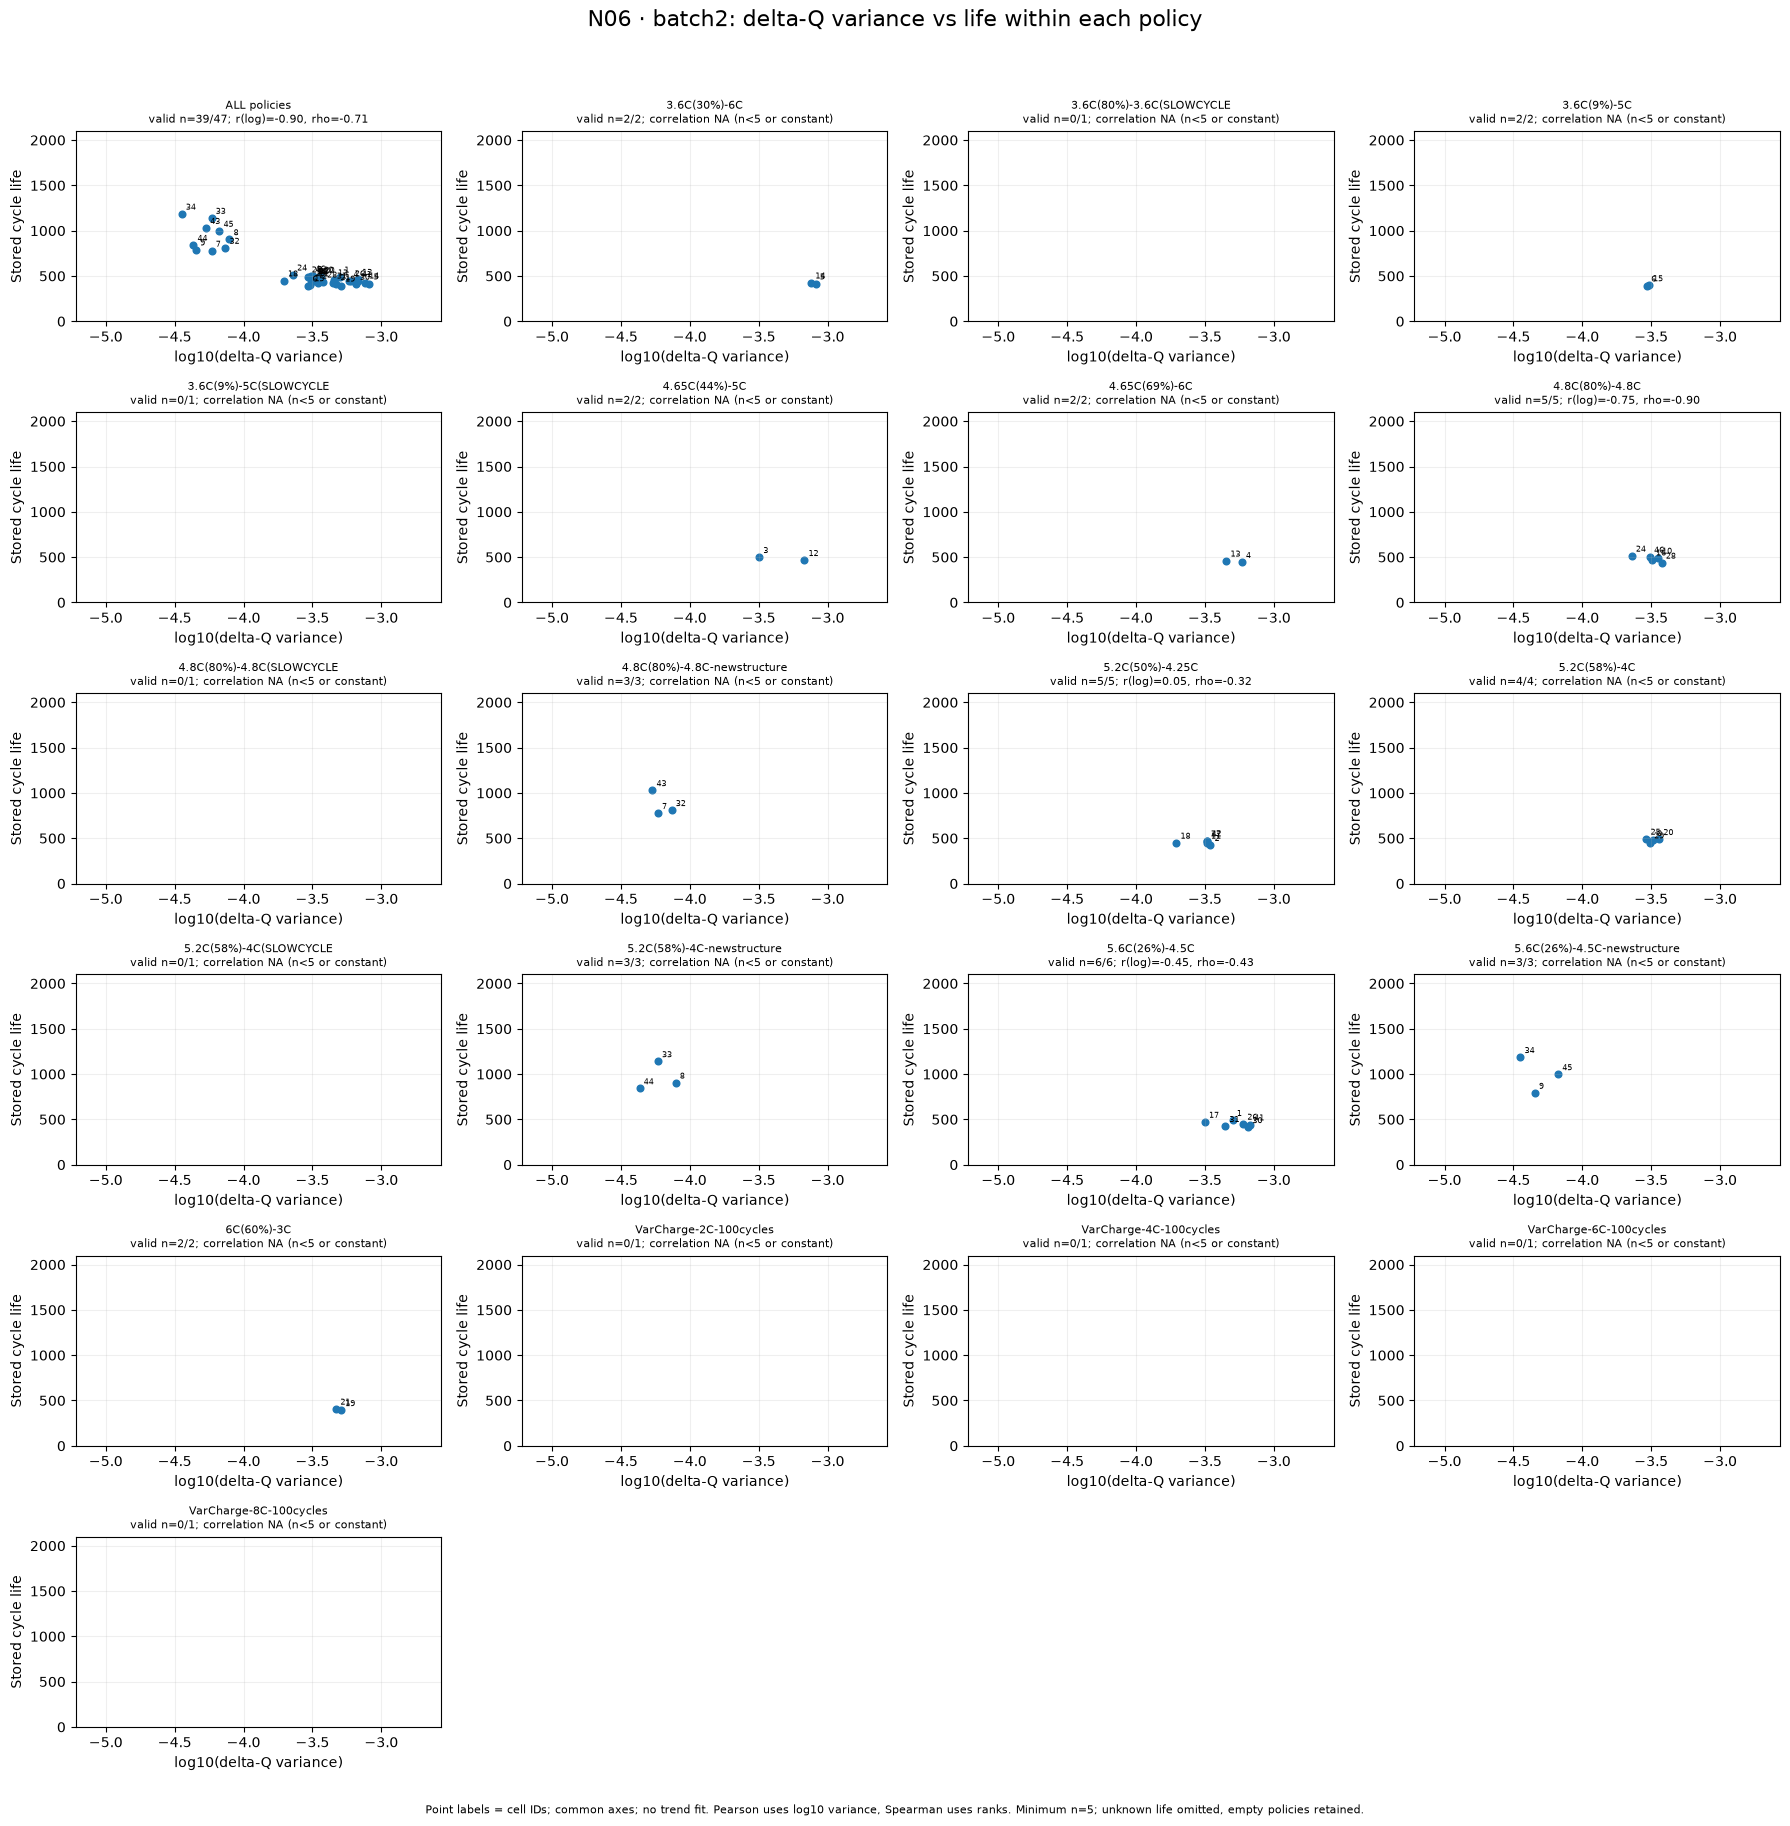

In [10]:
fig=pe.figure_within_policy(features,'batch2',group_stats)
fig.savefig(OUTPUT_DIR/'N06_batch2_within_policy.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

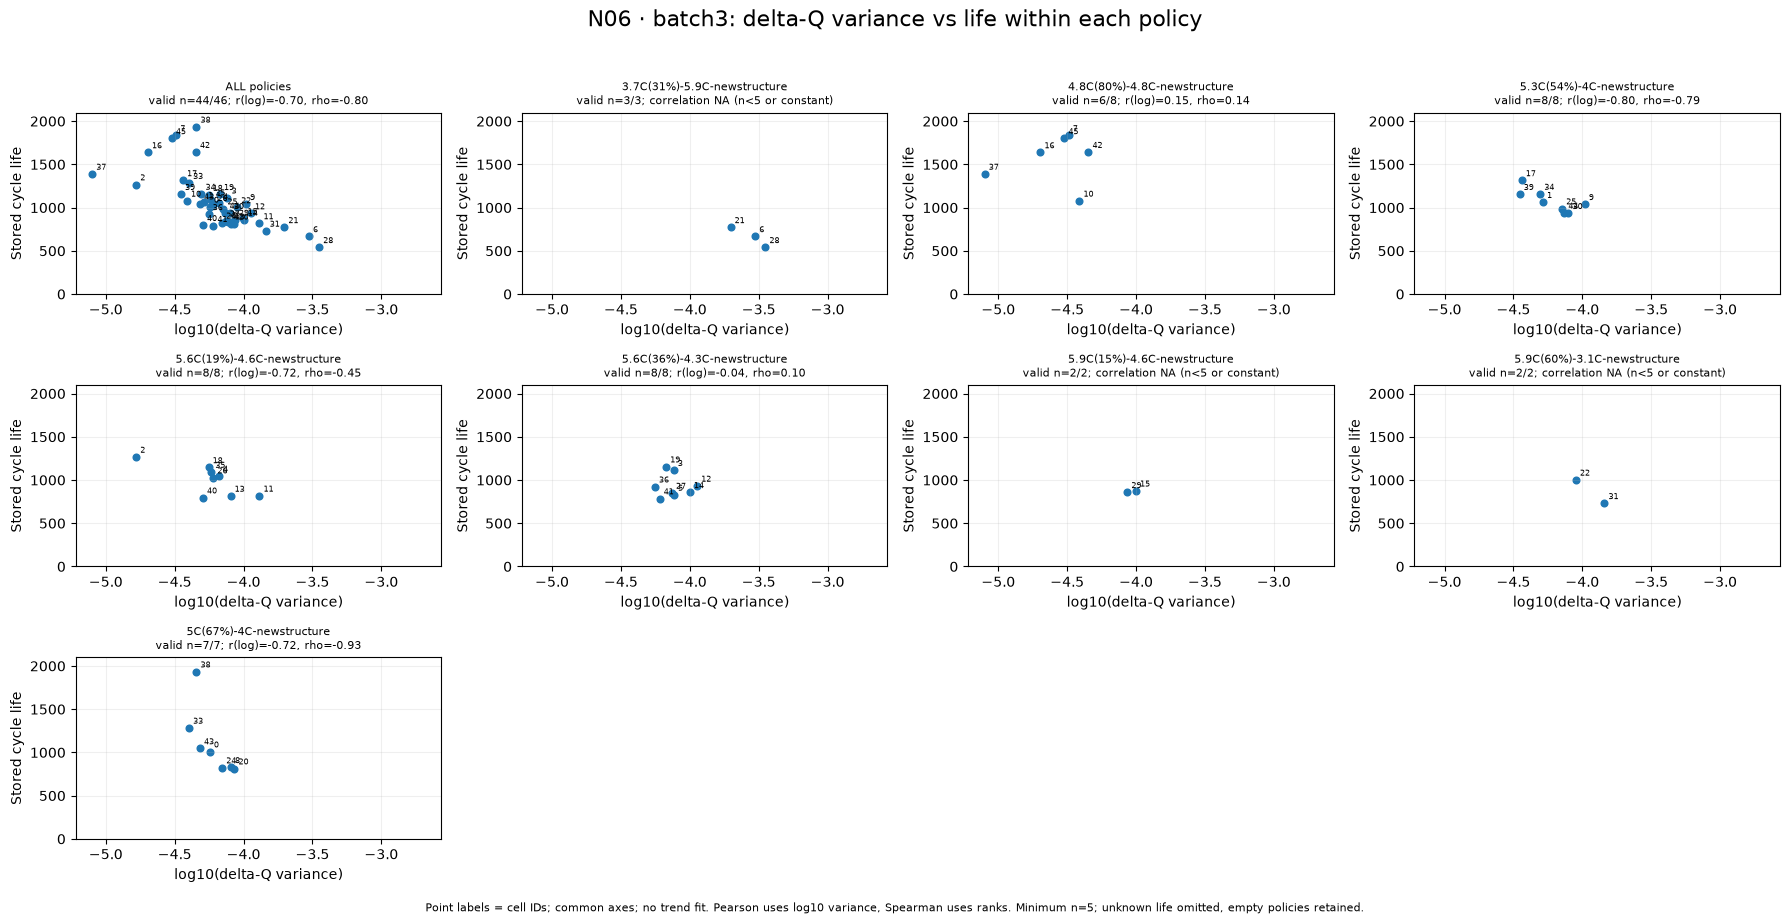

In [11]:
fig=pe.figure_within_policy(features,'batch3',group_stats)
fig.savefig(OUTPUT_DIR/'N06_batch3_within_policy.png',dpi=130,bbox_inches='tight')
plt.show()
plt.close(fig)

In [12]:
display(group_stats[group_stats.status.eq('computed')])

,batch,group_type,group,n,pearson_logvar,spearman,status
23,batch1,all,all,46,-0.886123,-0.871161,computed
24,batch1,life_group,long (>1000),10,-0.837841,-0.793939,computed
25,batch1,life_group,medium (500–1000),36,-0.827563,-0.801133,computed
32,batch2,policy,4.8C(80%)-4.8C,5,-0.753864,-0.900000,computed
35,batch2,policy,5.2C(50%)-4.25C,5,0.045924,-0.316228,computed
39,batch2,policy,5.6C(26%)-4.5C,6,-0.445973,-0.428571,computed
46,batch2,all,all,39,-0.901883,-0.708979,computed
48,batch2,life_group,medium (500–1000),8,-0.821246,-0.428571,computed
49,batch2,life_group,short (<500),28,-0.291687,-0.287982,computed
52,batch3,policy,4.8C(80%)-4.8C-newstructure,6,0.145301,0.142857,computed


## 관찰 문서

실행 이미지와 확인한 수치는 [N04–N06 관찰 보고서](../outputs/reports/day1/policy_exploration_observation_report.md)에 정리한다. N07–N08은 다음 묶음이다.